# Final report calculations — 2026-08-10

Working notebook for the Pi$^2$ final report (`Pi2Su26/final_report/`): numbers
for the tables and final figure polish. First up: the **measured Bessel-window
range** for each optics configuration candidate of the report's `tab:configs`,
in the report format `L (z ∈ [lo, hi])` (meters, z from axicon 3).

| Candidate | Dataset | Envelope source (existing reduction caches) |
|---|---|---|
| #1 baseline | jul22–23 (+ jul13 manual) | `onaxis_reduction_2026_07_23.json` (0.15 mm-aperture on-axis rate) + `axial_reduction_2026_07_23.json` manual `peak_rate` |
| #2 input beam 2× | jul29–30 | `ax3_reduction_2026_07_29.json` per-slice peak-pixel rate |
| #3 smaller hollow beam | aug5–6 direct | `ax3_core_frames_2026_08_06.csv` best unsaturated core-frame rate |
| #4 = #3 + 2× telescope in zone | aug5–6 telescope | `telescope_core_frames_2026_08_06.csv` — **image-side** $z'$ after f_200mm; image↔object offset NOT recorded, so no object-side mapping yet |

Method: per y, envelope = max unsaturated rate across runs/frames; window =
FWHM about the global peak (linear-interpolated half crossings, walking out
from the peak). Edges beyond the scanned span are reported as unbounded.

Caveats (candidates #1–#2 especially): same-y runs differ up to ~2× in
absolute rate (independent exposure cal + laser drift), and #1's gantry
estimator (aperture mean) differs from the others (peak pixel) — the FWHM
uses only relative shape within one dataset, but the max-over-runs envelope
can inherit steps at run boundaries. Real sub-half dips inside the window
(jul29: ~1.70/1.85 m) are printed as warnings, not excluded.

In [169]:
import csv
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent
RED = Path("reductions")

# simulator import (not needed for the measured ranges, kept for later cells);
# webapp repo has both historical spellings
for _name in ("bessel_beam_webapp",):  # NB trailing comma: bare ("x") iterates characters
    if (REPO.parent / _name).exists():
        sys.path.insert(0, str(REPO.parent / _name))
        break

NOTEBOOK_STEM = "final_report_calcs_2026_08_10"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.savefig(path, dpi=800, bbox_inches="tight")
    print(f"saved {path}")

In [170]:
# --- measured Bessel-window ranges, all four candidates ----------------------
# 1. build per-candidate axial envelopes from the existing reduction caches
#    (per y: max unsaturated rate across runs/frames; no raw frames touched)
# 2. FWHM about the global peak: walk out from the peak to the first sample
#    below half, linear-interpolate the crossing; data ending first => edge
#    unbounded (None)
# 3. print each result in the report format  L ($z \in [lo, hi]$)


def envelope(pairs):
    d = {}
    for y, r in pairs:
        d[y] = max(d.get(y, 0.0), r)
    ys = np.array(sorted(d))
    return ys, np.array([d[y] for y in ys])


def fwhm(ys, I):
    i = int(np.argmax(I))
    half = 0.5 * I[i]
    lo = hi = None
    for j in range(i, -1, -1):
        if I[j] < half:
            lo = np.interp(half, [I[j], I[j + 1]], [ys[j], ys[j + 1]])
            break
    for j in range(i, len(I)):
        if I[j] < half:
            # NB np.interp needs INCREASING xp — [I[j-1], I[j]] here is
            # decreasing and silently returns garbage (bug found 08-10 when
            # #4's upper edge came out 0.95 instead of 0.79)
            hi = np.interp(half, [I[j], I[j - 1]], [ys[j], ys[j - 1]])
            if ys[j] - ys[j - 1] > 2.5:
                print(f"  NOTE upper crossing interpolated across a "
                      f"{(ys[j] - ys[j - 1]):.0f} cm data gap "
                      f"[{ys[j - 1] / 100:.2f}, {ys[j] / 100:.2f}] m")
            break
    dips = [float(ys[j]) for j in range(len(I))
            if (lo or ys[0]) < ys[j] < (hi or ys[-1]) and I[j] < half]
    return dict(y_peak=ys[i], peak=I[i], half=half, lo=lo, hi=hi, dips=dips)


def report(name, ys, I, unit="z"):
    w = fwhm(ys, I)
    lo = None if w["lo"] is None else w["lo"] / 100
    hi = None if w["hi"] is None else w["hi"] / 100
    if lo is not None and hi is not None:
        txt = f"{hi - lo:.2f} (${unit} \\in [{lo:.2f}, {hi:.2f}]$)"
    else:
        span = (f"[{'?' if lo is None else f'{lo:.2f}'}, "
                f"{'?' if hi is None else f'{hi:.2f}'}]")
        txt = (f"UNBOUNDED {span} — scan span "
               f"[{ys[0] / 100:.2f}, {ys[-1] / 100:.2f}] m")
    print(f"{name}\n  peak {w['peak']:.3g} c/us at {w['y_peak'] / 100:.2f} m"
          f"   ->  {txt}")
    print(w)
    if w["dips"]:
        print(f"  WARNING sub-half dips inside window at y = "
              f"{[round(d / 100, 2) for d in w['dips']]} m")
    return (ys, I, w, name)


ENV = {}

# --- #1 baseline: jul22-23 gantry on-axis + jul13 manual ---------------------
onax = json.load(open(RED / "onaxis_reduction_2026_07_23.json"))
ys, I = envelope([(e["beam_y_cm"], e["onax_rate"]) for e in onax
                  if not e["sat_flag"]])
ENV["#1 gantry (on-axis 0.15 mm aperture)"] = report(
    "#1 baseline — jul22-23 gantry", ys, I)

man = json.load(open(RED / "axial_reduction_2026_07_23.json"))["manual"]
# manual runs renamed *_EXCLUDED on disk (REPO/data) are dropped — the
# reduction JSON predates the renames, so match by run-name prefix; when
# data/ is unavailable (container execution) fall back to the known list
_man_dir = REPO / "data"
EXCLUDED_MANUAL = ({p.name[:-len("_EXCLUDED")]
                    for p in _man_dir.glob("manual_scan-*_EXCLUDED")}
                   if _man_dir.exists()
                   else {"manual_scan-2026-07-13_17-15-59"})  # z=140 cm dip
if EXCLUDED_MANUAL:
    print(f"manual runs excluded: {sorted(EXCLUDED_MANUAL)}")
ys, I = envelope([(e["z_cm"], e["peak_rate"]) for e in man
                  if e.get("z_reference") == "axicon3"
                  and e["run"] not in EXCLUDED_MANUAL])
ENV["#1 manual jul13 (peak pixel)"] = report(
    "#1 baseline — jul13 manual", ys, I)

# --- #2 input 2x: jul29-30 per-slice peak rates ------------------------------
ax3 = json.load(open(RED / "ax3_reduction_2026_07_29.json"))
EXCLUDE_RUNS = {"auto_scan-2026-07-29_13-03-58"}
ys, I = envelope([(e["beam_y_cm"], e["peak"]["rate"]) for e in ax3
                  if e["run"] not in EXCLUDE_RUNS
                  and e["n_sat"] == 0 and not e["lower_bound"]])
ENV["#2 (peak pixel)"] = report("#2 input 2x — jul29-30", ys, I)

# --- #3 direct & #4 telescope: aug5-6 core-frame CSVs ------------------------
# NB the aug6 CSVs currently contain BOTH placement families (cache
# regeneration collision) — filter by frame-name prefix, not by file.
for cand, f, pref, unit in (
        ("#3 smaller hollow beam — aug5-6 direct",
         "ax3_core_frames_2026_08_06.csv",
         ("aug5_axicon3", "aug6_axicon3"), "z"),
        ("#4 = #3 + 2x telescope in zone (IMAGE-side z' after f_200mm)",
         "telescope_core_frames_2026_08_06.csv",
         ("aug6_telescope",), "z'")):
    rows = [r for r in csv.DictReader(open(RED / f))
            if r["excluded_run"] == "False" and int(r["n_sat_px"]) == 0
            and r["frame"].startswith(pref)]
    ys, I = envelope([(float(r["beam_y_cm"]), float(r["rate_c_per_us"]))
                      for r in rows])
    ENV[cand] = report(cand, ys, I, unit=unit)

  NOTE upper crossing interpolated across a 4 cm data gap [1.68, 1.71] m
#1 baseline — jul22-23 gantry
  peak 0.106 c/us at 1.44 m   ->  0.43 ($z \in [1.26, 1.69]$)
{'y_peak': np.float64(144.0), 'peak': np.float64(0.10596748954178165), 'half': np.float64(0.05298374477089082), 'lo': np.float64(125.97920096080017), 'hi': np.float64(169.15430366731914), 'dips': []}
manual runs excluded: ['manual_scan-2026-07-13_17-15-59']
  NOTE upper crossing interpolated across a 5 cm data gap [1.60, 1.65] m
#1 baseline — jul13 manual
  peak 0.767 c/us at 1.55 m   ->  0.22 ($z \in [1.39, 1.61]$)
{'y_peak': np.float64(155.0), 'peak': np.float64(0.7667943668012548), 'half': np.float64(0.3833971834006274), 'lo': np.float64(139.08564756164603), 'hi': np.float64(161.08668836390513), 'dips': []}
#2 input 2x — jul29-30
  peak 0.603 c/us at 1.99 m   ->  UNBOUNDED [1.89, ?] — scan span [0.60, 2.01] m
{'y_peak': np.float64(199.0), 'peak': np.float64(0.6034632948827907), 'half': np.float64(0.30173164744139536), 'l

saved images/final_report_calcs_2026_08_10/measured_window_envelopes.png


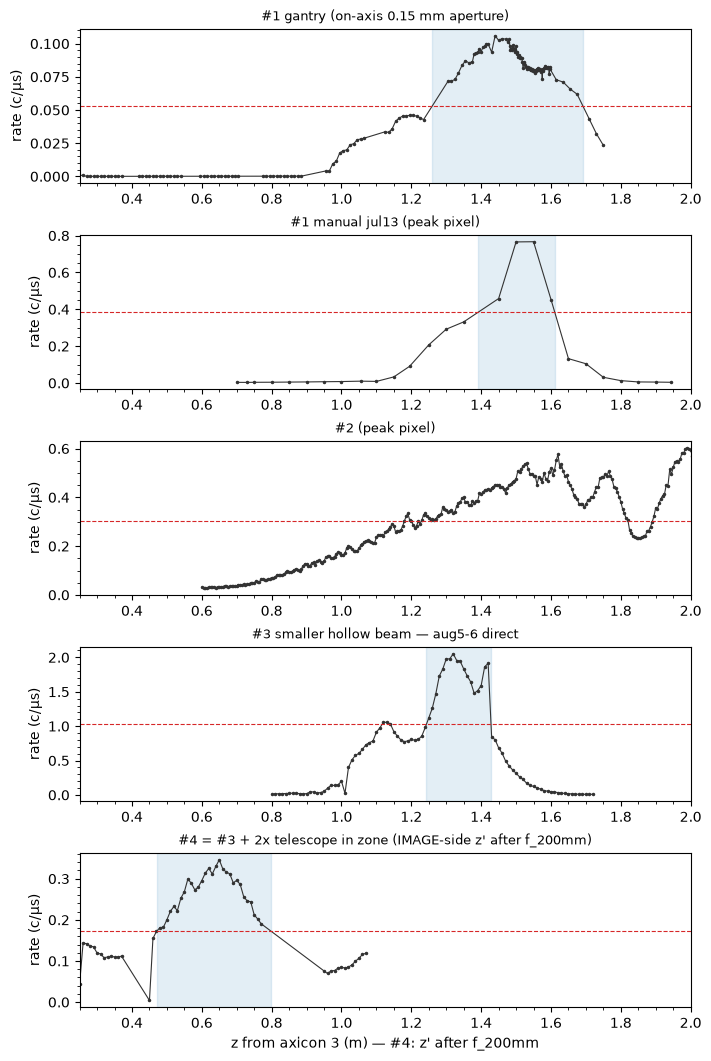

In [171]:
# --- envelope + window overview (sanity check of the crossings) --------------
fig, axes = plt.subplots(len(ENV), 1, figsize=(7, 2.1 * len(ENV)),
                         sharex=False, layout="constrained")
for ax, (label, (ys, I, w, _)) in zip(axes, ENV.items()):
    ax.plot(ys / 100, I, ".-", ms=3, lw=0.8, color="0.2")
    ax.axhline(w["half"], color="tab:red", lw=0.8, ls="--")
    if w["lo"] is not None and w["hi"] is not None:
        ax.axvspan(w["lo"] / 100, w["hi"] / 100, color="tab:blue", alpha=0.12)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel("rate (c/µs)")
    ax.set_xlim(0.25, 2.0)
    ax.minorticks_on()
axes[-1].set_xlabel("z from axicon 3 (m) — #4: z' after f_200mm")
save_fig("measured_window_envelopes")
plt.show()

## Fits-based measured windows (absolutely scaled J$_0^2$ amplitudes)

Same windows, better estimator: instead of the raw peak-pixel rate, the axial
envelope is the fitted central-lobe amplitude $A/T$ (counts/µs) from a radial
J$_0^2$ fit to each cached core thumbnail — robust to hot pixels and pixel
sampling, with per-point 1$\sigma$ errors and an rms/A quality cut
(`rms_r <= 0.06`, same as the central-lobe notebooks). Inputs are the existing
thumbnail caches; candidate #1 has no thumbnail cache, so it keeps the
peak-pixel/aperture result above.

Because the jul29 dips at ~1.70/1.85 m are real (they reproduce in the aug3
re-scan), the from-peak FWHM still degenerates for #2 — so both definitions
are printed: **from-peak** (walk out from the peak, comparable to the QDHT
column's definition) and **outermost 50\% crossings** with the deepest
in-window ripple quoted alongside. For profiles without sub-half ripple the
two coincide.

In [172]:
# --- fits-based axial envelopes + both window definitions --------------------
# 1. per dataset: join thumbnail cache -> core-frame CSV (exposure, n_sat_px);
#    fills-the-square filter (any NaN in crop = clipped -> skip)
# 2. per thumb: sub-pixel centroid, azimuthal-mean radial profile, fit
#    A*J0^2(k u) + C over |u| <= fit_half; keep k in 0.2-4x ideal_eff
# 3. per y: envelope = max A/T among clean fits (rms/A <= 0.06)
# 4. windows: from-peak FWHM (comparable to the model column) AND outermost
#    50% crossings + deepest in-window ripple
from scipy.optimize import curve_fit
from scipy.special import j0
from simulator.qdht_axicon import axicon_kr

KR3 = axicon_kr(0.5)
RMS_OK = 0.06


def j0sq(u_um, A, k, C):
    return A * j0(k * u_um * 1e-6) ** 2 + C


def radial_profile(t, um_per_px):
    # sub-pixel centroid: 3x3-mean argmax, then intensity-weighted in +-7 px
    s = t.copy()
    s[1:-1, 1:-1] = (t[:-2, :-2] + t[:-2, 1:-1] + t[:-2, 2:] +
                     t[1:-1, :-2] + t[1:-1, 1:-1] + t[1:-1, 2:] +
                     t[2:, :-2] + t[2:, 1:-1] + t[2:, 2:]) / 9.0
    iy, ix = np.unravel_index(np.argmax(s), s.shape)
    y0, y1 = max(iy - 7, 0), min(iy + 8, t.shape[0])
    x0, x1 = max(ix - 7, 0), min(ix + 8, t.shape[1])
    w = t[y0:y1, x0:x1]
    yy, xx = np.mgrid[y0:y1, x0:x1]
    cy, cx = (w * yy).sum() / w.sum(), (w * xx).sum() / w.sum()
    yy, xx = np.mgrid[:t.shape[0], :t.shape[1]]
    r_px = np.hypot(yy - cy, xx - cx)
    nb_ = np.round(r_px * 2).astype(int)  # half-pixel bins
    prof = np.bincount(nb_.ravel(), t.ravel()) / np.bincount(nb_.ravel())
    u_um = np.arange(len(prof)) * 0.5 * um_per_px
    return u_um, prof


def fit_thumb(t, um_per_px, k_ideal_eff, fit_half_um):
    u, I = radial_profile(t.astype(np.float32), um_per_px)
    ok = np.isfinite(I) & (u <= fit_half_um)
    p0 = [np.nanmax(I[ok]), k_ideal_eff, 0.0]
    popt, pcov = curve_fit(j0sq, u[ok], I[ok], p0=p0,
                           bounds=([0, 0.2 * k_ideal_eff, -np.inf],
                                   [np.inf, 4.0 * k_ideal_eff, np.inf]))
    resid = I[ok] - j0sq(u[ok], *popt)
    return popt, np.sqrt(np.diag(pcov)), np.sqrt(np.mean(resid**2)) / popt[0]


def window_outer(ys, I):
    i = int(np.argmax(I))
    half = 0.5 * I[i]
    above = I >= half
    lo = hi = None
    j = int(np.argmax(above))                  # first above-half sample
    if j > 0:
        lo = np.interp(half, [I[j - 1], I[j]], [ys[j - 1], ys[j]])
    j = len(I) - 1 - int(np.argmax(above[::-1]))   # last above-half sample
    if j < len(I) - 1:
        hi = np.interp(half, [I[j + 1], I[j]], [ys[j + 1], ys[j]])
    inw = (ys >= (lo or ys[0])) & (ys <= (hi or ys[-1]))
    ripple = I[inw].min() / I[i] if inw.any() else np.nan
    return dict(half=half, lo=lo, hi=hi, ripple=ripple, y_peak=ys[i], peak=I[i])


def exposures(csv_path):
    d = {}
    for r in csv.DictReader(open(csv_path)):
        if r["excluded_run"] == "False" and int(r["n_sat_px"]) == 0:
            d[(r["run"], r["frame"])] = float(r["exposure_us"])
    return d


# One dict per dataset:
#   label        - candidate name (report label; keys of FIT_ENV)
#   thumbs_npz   - cached core thumbnails (reductions/)
#   frames_csv   - core-frame CSV with per-frame exposure_us / n_sat_px
#   frame_prefix - keep only frames whose name starts with these placement
#                  prefixes; None = keep all (cache holds a single dataset).
#                  Needed for the aug6 caches, whose CSVs contain BOTH the
#                  direct and telescope placement families.
#   um_per_px    - thumbnail pixel pitch in um (fallback; the npz value wins)
#   fit_half_um  - radial J0^2 fit window, |u| <= this
#   mag          - transverse magnification M (fit k bounds scale as
#                  k_ideal/M; 2.0 for the in-zone telescope, else 1.0)
#   excluded_runs- run names dropped before fitting
FITSETS = (
    dict(label="#1 baseline — jul22-23 gantry",
         thumbs_npz="ax3_core_thumbs_2026_07_23.npz",
         frames_csv="ax3_core_frames_2026_07_23.csv",
         frame_prefix=None, um_per_px=6.9, fit_half_um=450.0, mag=1.0,
         excluded_runs=set()),
    dict(label="#2 input 2x — jul29-30",
         thumbs_npz="ax3_core_thumbs.npz",
         frames_csv="ax3_core_frames.csv",
         frame_prefix=None, um_per_px=6.9, fit_half_um=450.0, mag=1.0,
         excluded_runs={"auto_scan-2026-07-29_13-03-58"}),
    dict(label="#3 smaller hollow beam — aug5-6 direct",
         thumbs_npz="ax3_core_thumbs_2026_08_06.npz",
         frames_csv="ax3_core_frames_2026_08_06.csv",
         frame_prefix=("aug5_axicon3", "aug6_axicon3"),
         um_per_px=6.9, fit_half_um=450.0, mag=1.0, excluded_runs=set()),
    dict(label="#4 = #3 + 2x telescope (IMAGE-side z')",
         thumbs_npz="telescope_core_thumbs_2026_08_06.npz",
         frames_csv="telescope_core_frames_2026_08_06.csv",
         frame_prefix=("aug6_telescope",),
         um_per_px=13.8, fit_half_um=900.0, mag=2.0, excluded_runs=set()),
)

FIT_ENV = {}
for ds in FITSETS:
    name, pref = ds["label"], ds["frame_prefix"]
    fit_half, excl = ds["fit_half_um"], ds["excluded_runs"]
    z = np.load(RED / ds["thumbs_npz"], allow_pickle=True)
    um_px = (float(z["um_per_px"]) if "um_per_px" in z.files
             else ds["um_per_px"])
    T_exp = exposures(RED / ds["frames_csv"])
    k_eff = KR3 / ds["mag"]
    best = {}
    n_nan = n_noexp = n_fail = 0
    for t, y, run, fr in zip(z["thumbs"], z["ys_cm"], z["runs"], z["frames"]):
        if pref and not str(fr).startswith(pref):
            continue
        if str(run) in excl:
            continue
        if np.isnan(np.asarray(t, dtype=np.float32)).any():
            n_nan += 1
            continue
        T = T_exp.get((str(run), str(fr)))
        if T is None:
            n_noexp += 1  # saturated/excluded per CSV, or cache/CSV drift
            continue
        try:
            (A, k, C), perr, rms = fit_thumb(np.asarray(t), um_px, k_eff, fit_half)
        except RuntimeError:
            n_fail += 1
            continue
        if rms > RMS_OK:
            continue
        rate, err = A / T, perr[0] / T
        yy = float(y)
        if yy not in best or rate > best[yy][0]:
            best[yy] = (rate, err)
    ys = np.array(sorted(best))
    I = np.array([best[y][0] for y in ys])
    E = np.array([best[y][1] for y in ys])
    print(f"{name}: {len(ys)} y points "
          f"(skipped: {n_nan} clipped, {n_noexp} no-CSV/sat, {n_fail} no-fit)")
    report(f"  from-peak: {name}", ys, I)
    w = window_outer(ys, I)
    lo = "?" if w["lo"] is None else f"{w['lo'] / 100:.2f}"
    hi = "?" if w["hi"] is None else f"{w['hi'] / 100:.2f}"
    if w["lo"] is not None and w["hi"] is not None:
        span = f"{(w['hi'] - w['lo']) / 100:.2f} ($z \\in [{lo}, {hi}]$)"
    else:
        span = f"UNBOUNDED [{lo}, {hi}] — scan span [{ys[0]/100:.2f}, {ys[-1]/100:.2f}] m"
    print(f"  outermost 50%: {span}   deepest in-window ripple "
          f"{100 * w['ripple']:.0f}% of peak\n")
    FIT_ENV[name] = (ys, I, E, w)

/var/folders/nw/zxrvk8454ynch8kmyr_9zx180000gn/T/ipykernel_75395/2694268656.py:36: RuntimeWarning: invalid value encountered in divide
  prof = np.bincount(nb_.ravel(), t.ravel()) / np.bincount(nb_.ravel())


#1 baseline — jul22-23 gantry: 157 y points (skipped: 402 clipped, 0 no-CSV/sat, 1 no-fit)
  NOTE upper crossing interpolated across a 4 cm data gap [1.68, 1.71] m
  from-peak: #1 baseline — jul22-23 gantry
  peak 0.723 c/us at 1.48 m   ->  0.38 ($z \in [1.29, 1.68]$)
{'y_peak': np.float64(148.0), 'peak': np.float64(0.722603134748571), 'half': np.float64(0.3613015673742855), 'lo': np.float64(129.4398385240865), 'hi': np.float64(167.73532870385475), 'dips': []}
  outermost 50%: 0.38 ($z \in [1.29, 1.68]$)   deepest in-window ripple 52% of peak

#2 input 2x — jul29-30: 272 y points (skipped: 320 clipped, 0 no-CSV/sat, 0 no-fit)
  from-peak: #2 input 2x — jul29-30
  peak 0.59 c/us at 1.99 m   ->  UNBOUNDED [1.89, ?] — scan span [0.60, 2.01] m
{'y_peak': np.float64(198.5), 'peak': np.float64(0.5903458876129589), 'half': np.float64(0.29517294380647946), 'lo': np.float64(188.9349527769886), 'hi': None, 'dips': []}
  outermost 50%: UNBOUNDED [1.18, ?] — scan span [0.60, 2.01] m   deepest in-w

saved images/final_report_calcs_2026_08_10/measured_window_envelopes_fits.png


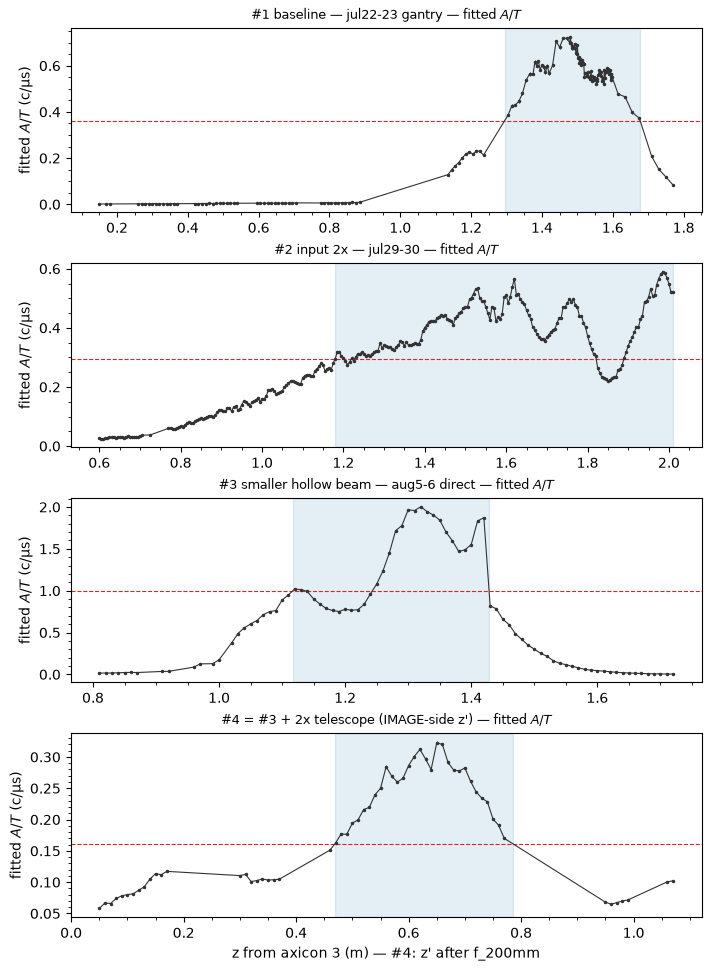

In [173]:
# --- fits-based envelopes: both window definitions overlaid ------------------
fig, axes = plt.subplots(len(FIT_ENV), 1, figsize=(7, 2.4 * len(FIT_ENV)),
                         layout="constrained")
for ax, (label, (ys, I, E, w)) in zip(np.atleast_1d(axes), FIT_ENV.items()):
    ax.errorbar(ys / 100, I, yerr=E, fmt=".-", ms=3, lw=0.8, color="0.2",
                elinewidth=0.6)
    ax.axhline(w["half"], color="tab:red", lw=0.8, ls="--")
    if w["lo"] is not None or w["hi"] is not None:
        ax.axvspan((w["lo"] or ys[0]) / 100, (w["hi"] or ys[-1]) / 100,
                   color="tab:blue", alpha=0.12)
    ax.set_title(label + " — fitted $A/T$", fontsize=9)
    ax.set_ylabel("fitted $A/T$ (c/µs)")
    # ax.set_yscale("log")
    ax.minorticks_on()
np.atleast_1d(axes)[-1].set_xlabel("z from axicon 3 (m) — #4: z' after f_200mm")
save_fig("measured_window_envelopes_fits")
plt.show()

cut at dip trough y = 1.85 m (envelope 0.220 c/us there); 240/272 points kept

#2 MAIN PLATEAU (final peak excluded)
  peak 0.566 c/us at 1.62 m   ->  0.61 ($z \in [1.21, 1.82]$)
{'y_peak': np.float64(162.0), 'peak': np.float64(0.5661182534963578), 'half': np.float64(0.2830591267481789), 'lo': np.float64(121.45438710482897), 'hi': np.float64(182.2624348468528), 'dips': []}
  outermost 50%: 0.65 ($z \in [1.18, 1.82]$)   deepest in-window ripple 49% of peak
saved images/final_report_calcs_2026_08_10/cand2_window_no_final_peak.png


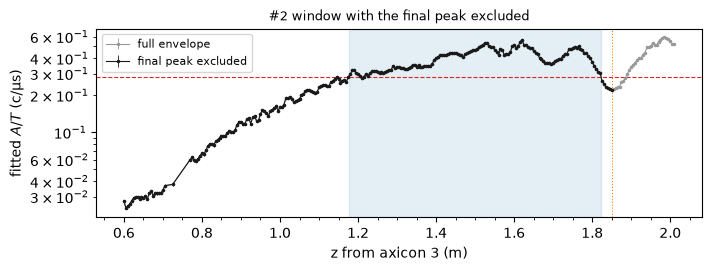

In [174]:
# --- #2 variant: exclude the final peak, re-derive the window ----------------
# Rationale to weigh: the final rise (peak 0.59 c/us at 1.99 m) sits right
# where QDHT puts the window peak (~1.88 m) and is cut off by the scan end at
# 2.01 m, so the full-envelope window is unbounded above. Cutting the
# envelope at the dip trough before the final rise gives the bounded window
# of the MAIN PLATEAU instead. Quote it only as such — it deliberately
# understates the full window.
ys2, I2, E2, _ = FIT_ENV["#2 input 2x — jul29-30"]

m = (ys2 >= 175) & (ys2 <= 199)               # bracket the last dip trough
y_cut = ys2[m][np.argmin(I2[m])]
keep = ys2 <= y_cut
print(f"cut at dip trough y = {y_cut / 100:.2f} m "
      f"(envelope {I2[m].min():.3f} c/us there); "
      f"{keep.sum()}/{len(ys2)} points kept\n")

report("#2 MAIN PLATEAU (final peak excluded)", ys2[keep], I2[keep])
w = window_outer(ys2[keep], I2[keep])
lo = "?" if w["lo"] is None else f"{w['lo'] / 100:.2f}"
hi = "?" if w["hi"] is None else f"{w['hi'] / 100:.2f}"
length = "" if None in (w["lo"], w["hi"]) else f"{(w['hi'] - w['lo']) / 100:.2f} "
print(f"  outermost 50%: {length}($z \\in [{lo}, {hi}]$)   "
      f"deepest in-window ripple {100 * w['ripple']:.0f}% of peak")

fig, ax = plt.subplots(figsize=(7, 2.6), layout="constrained")
ax.errorbar(ys2 / 100, I2, yerr=E2, fmt=".-", ms=3, lw=0.8, color="0.6",
            elinewidth=0.6, label="full envelope")
ax.errorbar(ys2[keep] / 100, I2[keep], yerr=E2[keep], fmt=".-", ms=3, lw=0.8,
            color="0.1", elinewidth=0.6, label="final peak excluded")
ax.axhline(w["half"], color="tab:red", lw=0.8, ls="--")
if w["lo"] is not None and w["hi"] is not None:
    ax.axvspan(w["lo"] / 100, w["hi"] / 100, color="tab:blue", alpha=0.12)
ax.axvline(y_cut / 100, color="tab:orange", lw=0.8, ls=":")
ax.set_xlabel("z from axicon 3 (m)")
ax.set_ylabel("fitted $A/T$ (c/µs)")
ax.set_yscale("log")
ax.minorticks_on()
ax.legend(fontsize=8)
ax.set_title("#2 window with the final peak excluded", fontsize=9)
save_fig("cand2_window_no_final_peak")
plt.show()

## Placement / drift comparison figure (report)

Self-contained port of the `placement_cmp_report` cell from
`axicon3_placement_comparison_2026_08_03`: candidate #2's placement 009
measured on jul29 (run 15-56-42) vs its aug3 re-placement (runs 15-06-23 +
15-31-36), at z = 175 and 179 cm. One figure showing fit quality
(rms/A ≲ 1%), reproducibility of the $k_r$ anomaly across an independent
re-alignment, the aug3 $k_x$–$k_y$ split (astigmatism), and 5-day amplitude
drift. Everything is normalized to the single global peak (brightest fitted
amplitude among the picks), so the axis is [0, 1] but all panels share one
absolute scale.

**Report axis convention** (differs from the gantry/dataset naming): x =
horizontal image axis, y = vertical image axis, z = propagation. The dataset
calls those x, z, y respectively.

Inputs are `reductions/placement_cmp_core_thumbs.npz` +
`placement_cmp_dark_stats.csv`; per-frame y/exposure comes from the runs'
`frames.jsonl` when `profiler/data` is present and is cached to
`reductions/placement_cmp_frame_info.csv` for cache-only reruns.

{(175, 'jul29'): ('auto_scan-2026-07-29_15-56-42', np.float64(0.484)), (180, 'jul29'): ('auto_scan-2026-07-29_15-56-42', np.float64(0.376)), (175, 'aug3'): ('auto_scan-2026-08-03_15-31-36', np.float64(0.334)), (180, 'aug3'): ('auto_scan-2026-08-03_15-31-36', np.float64(0.333))}
global peak G = 0.484 c/us (auto_scan-2026-07-29_15-56-42)


/var/folders/nw/zxrvk8454ynch8kmyr_9zx180000gn/T/ipykernel_75395/284973892.py:181: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0.5, h_pad=0.5, w_pad=2, rect=[0.035, 0.0, 1.0, 0.93])


saved images/final_report_calcs_2026_08_10/placement_cmp_report.png


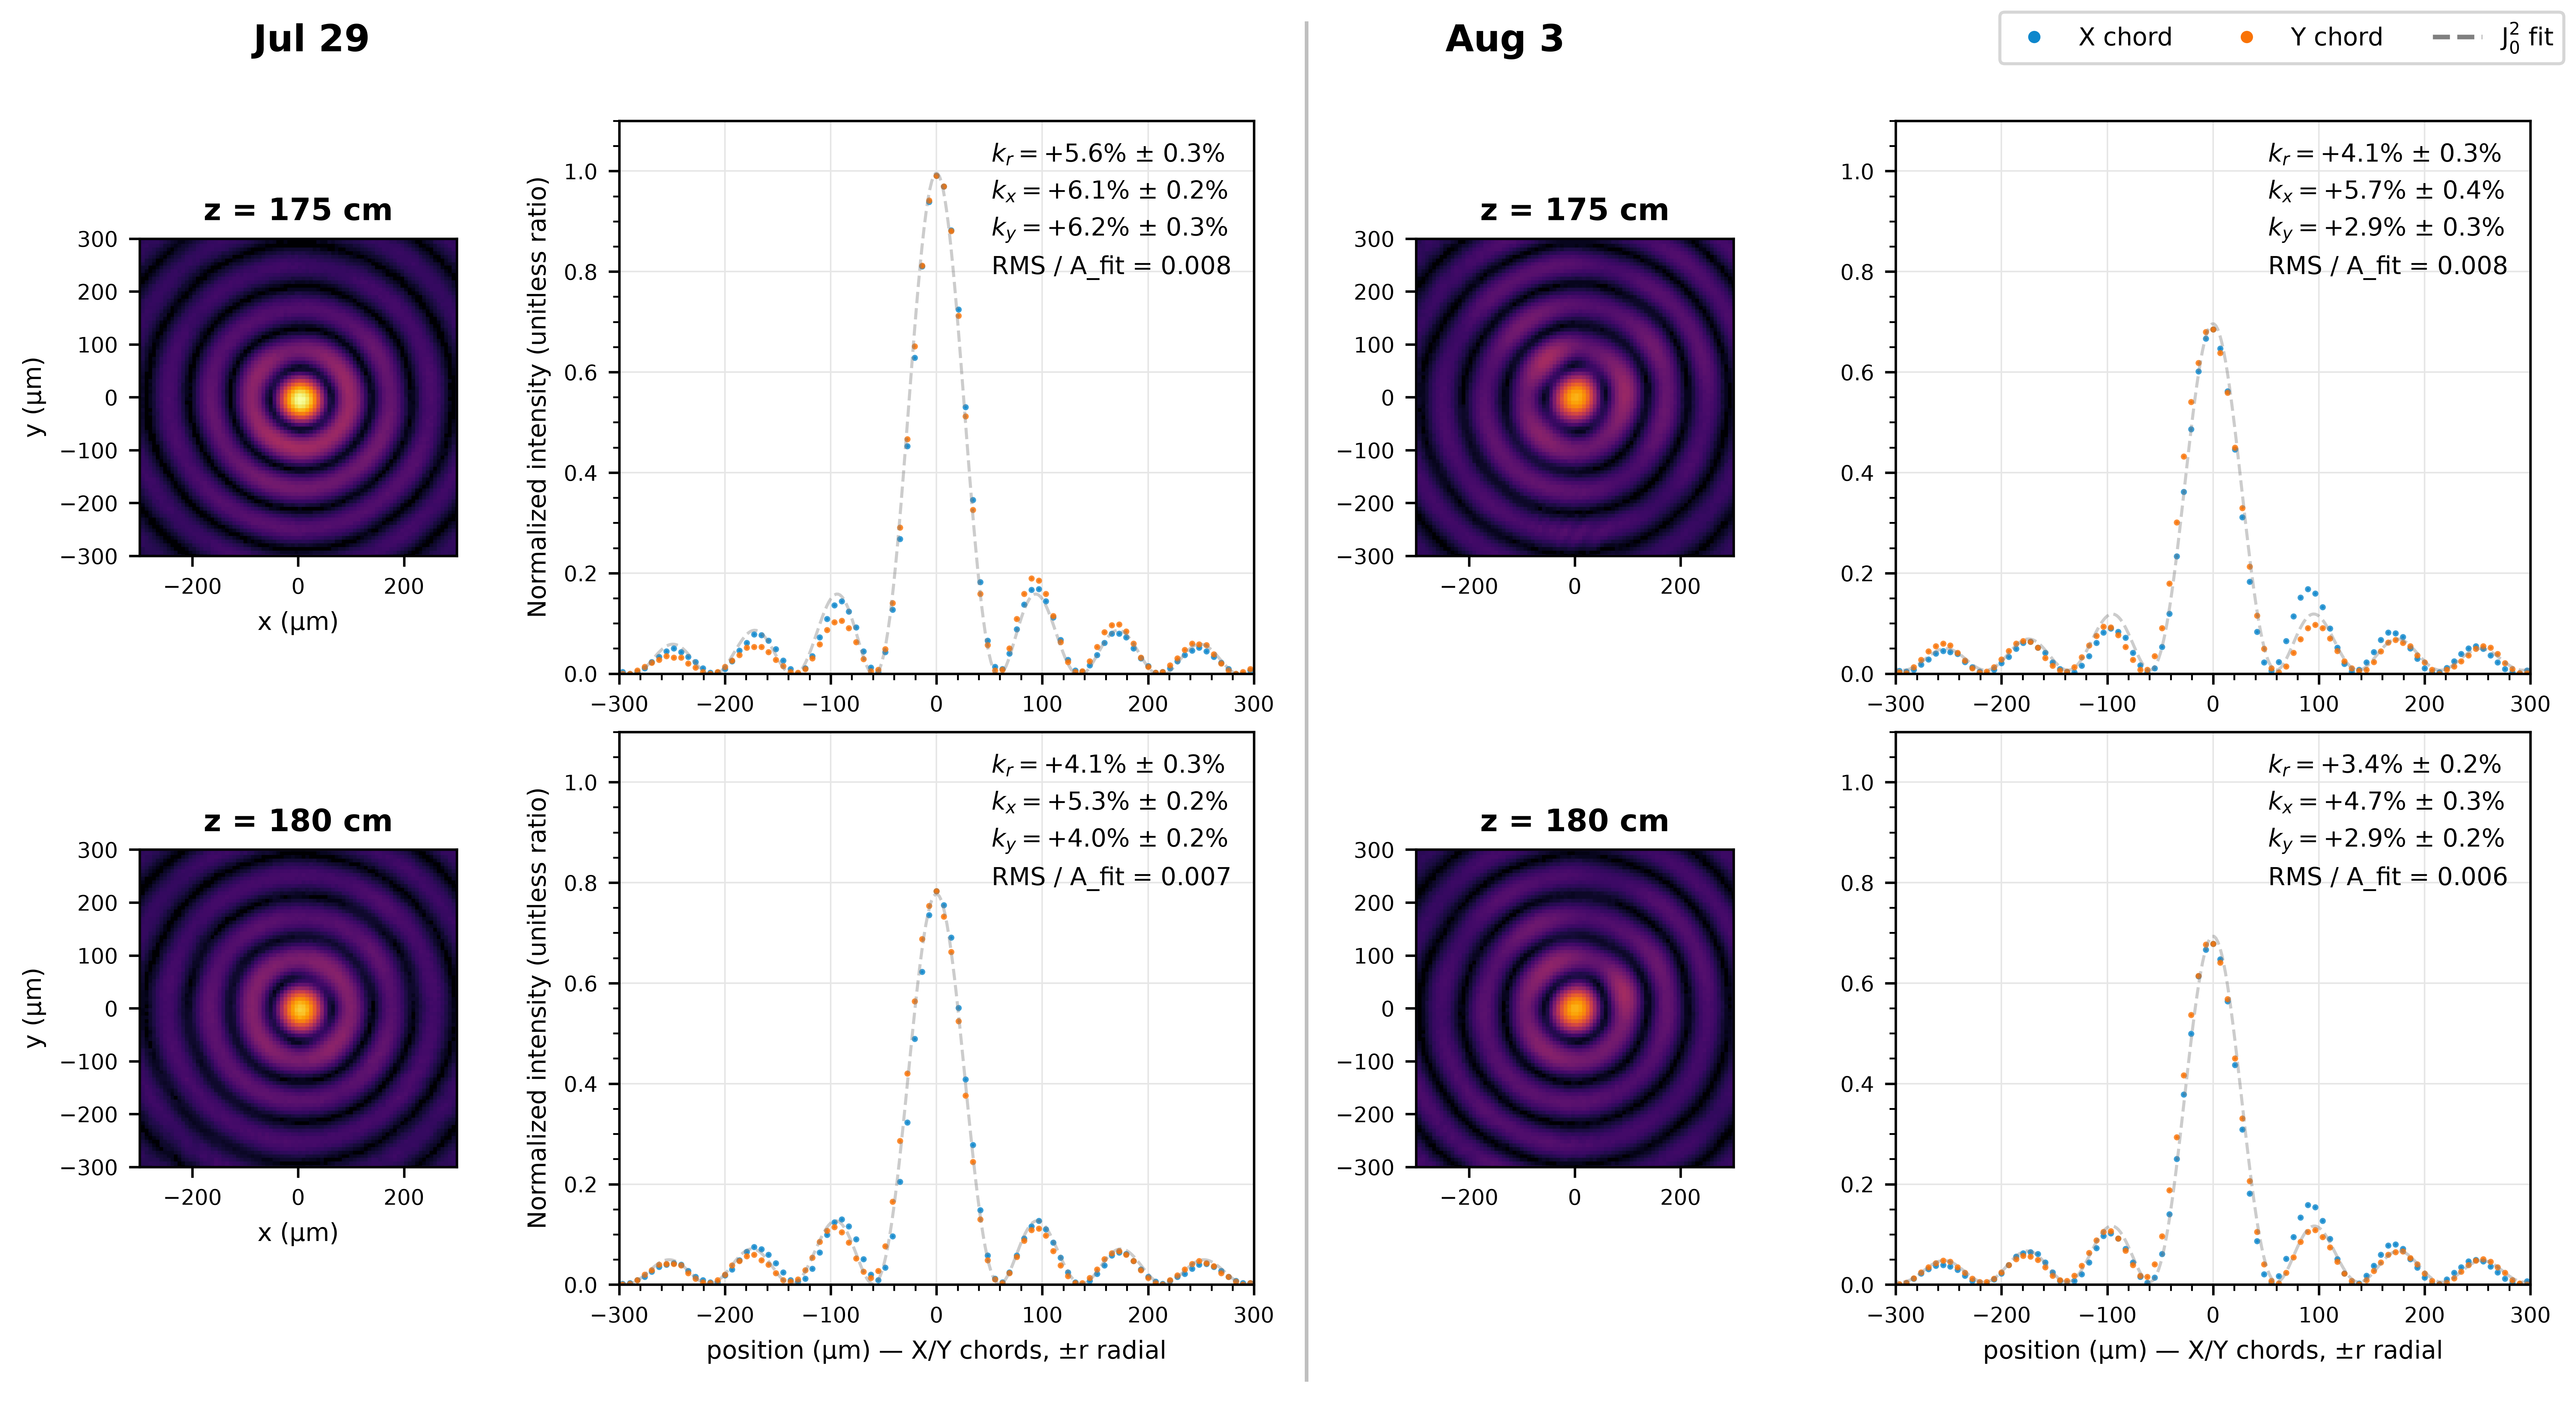

In [175]:
# --- placement/drift comparison (candidate #2, jul29 vs aug3) ----------------
# 1. per-frame info (y, exposure, slice, n_sat_px) from frames.jsonl,
#    cached to placement_cmp_frame_info.csv
# 2. rate thumbnails (I - I_dark_slice)/T from the placement thumb cache
# 3. per (z row, day): pick the largest-radial-A unsaturated, fully-filled
#    frame at that y; fits identical to the placement notebook — radial
#    (azimuthal mean about the 5x5 sub-pixel centroid, u0 = 0) and X/Y
#    chords (free center, |u0| <= 35 um), k bounded 0.5-1.5x ideal,
#    1-sigma errors = sqrt(diag(pcov))
# NB aug3 needs BOTH runs for rows 175/180: 15-06-23 is the aborted start
# (y 170-173.5 only); the re-anchored 15-31-36 (y 173-180) is where the
# 175/180 cm frames live. PC_RUNS genuinely filters the candidates below.
PC_RUNS = {"jul29": ["auto_scan-2026-07-29_15-56-42"],
           "aug3": ["auto_scan-2026-08-03_15-06-23",
                    "auto_scan-2026-08-03_15-31-36"]}
PC_RUN_SET = {r for rr in PC_RUNS.values() for r in rr}
ROWS_RPT = [175, 180]
PC_INFO_CSV = RED / "placement_cmp_frame_info.csv"
PC_FIT_HALF = 450.0
PC_UM_PX = 6.9


def pc_j0sq(u_um, A, k, u0_um, Cc):
    return A * j0(k * (u_um - u0_um) * 1e-6) ** 2 + Cc


def pc_fit(u_um, I, free_center):
    ok = np.isfinite(I) & (np.abs(u_um) <= PC_FIT_HALF)
    u0m = 35.0 if free_center else 1e-9
    popt, pcov = curve_fit(pc_j0sq, u_um[ok], I[ok],
                           p0=[np.nanmax(I[ok]), KR3, 0.0, 0.0],
                           bounds=([0, 0.5 * KR3, -u0m, -np.inf],
                                   [np.inf, 1.5 * KR3, u0m, np.inf]))
    resid = I[ok] - pc_j0sq(u_um[ok], *popt)
    return popt, np.sqrt(np.diag(pcov)), np.sqrt(np.mean(resid**2)) / popt[0]


if not PC_INFO_CSV.exists():
    rows_i = []
    for day, runs_ in PC_RUNS.items():
        for run in runs_:
            mf = REPO / "profiler/data" / run / "frames.jsonl"
            for ln, line in enumerate(open(mf)):
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    print(f"WARNING {run}: bad manifest line {ln} skipped")
                    continue
                ex = rec.get("Extra", {})
                if (ex.get("ScanKind") != "AutoBeamStack"
                        or Path(rec["Path"]).stem.endswith("-dark")):
                    continue
                rows_i.append(dict(day=day, run=run,
                                   frame=Path(rec["Path"]).name,
                                   slice=ex["Subfolder"],
                                   y_cm=ex["BeamY_mm"] / 10.0,
                                   exposure_us=ex["Exposure_us"],
                                   n_sat_px=rec.get("SaturatedPixelCount", 0)))
    with open(PC_INFO_CSV, "w", newline="") as fo:
        w = csv.DictWriter(fo, fieldnames=list(rows_i[0]))
        w.writeheader(); w.writerows(rows_i)
    print(f"built {PC_INFO_CSV.name}: {len(rows_i)} frames")
PC_INFO = {(r["run"], r["frame"]): r for r in csv.DictReader(open(PC_INFO_CSV))}
PC_DARK = {(r["run"], r["slice"]): float(r["dark_mean"])
           for r in csv.DictReader(open(RED / "placement_cmp_dark_stats.csv"))}

_z = np.load(RED / "placement_cmp_core_thumbs.npz", allow_pickle=True)
pc_cands = []
for t, run, fr in zip(_z["thumbs"], _z["runs"], _z["frames"]):
    if str(run) not in PC_RUN_SET:
        continue
    inf = PC_INFO.get((str(run), str(fr)))
    if inf is None or int(inf["n_sat_px"]) > 0:
        continue
    t32 = np.asarray(t, dtype=np.float32)
    if np.isnan(t32).any():
        continue
    y_cm = float(inf["y_cm"])
    if min(abs(y_cm - y0) for y0 in ROWS_RPT) > 0:
        continue
    rt = ((t32 - PC_DARK.get((str(run), inf["slice"]), 0.0))
          / float(inf["exposure_us"]))
    # 5x5 sub-pixel centroid about the peak -> radial profile (1-px bins)
    py, px_ = np.unravel_index(np.nanargmax(rt), rt.shape)
    w = rt[max(py - 2, 0):py + 3, max(px_ - 2, 0):px_ + 3]
    wy, wx = np.mgrid[max(py - 2, 0):py + 3, max(px_ - 2, 0):px_ + 3]
    cy, cx = (w * wy).sum() / w.sum(), (w * wx).sum() / w.sum()
    yy, xx = np.mgrid[:rt.shape[0], :rt.shape[1]]
    r_um = np.hypot(yy - cy, xx - cx) * PC_UM_PX
    b = (r_um / PC_UM_PX).astype(int)
    prof = np.bincount(b.ravel(), rt.ravel()) / np.maximum(np.bincount(b.ravel()), 1)
    r_cent = (np.arange(len(prof)) + 0.5) * PC_UM_PX
    x_u = (np.arange(rt.shape[1]) - px_) * PC_UM_PX
    z_u = (np.arange(rt.shape[0]) - py) * PC_UM_PX
    try:
        pr, er, rms_r = pc_fit(r_cent, prof, free_center=False)
        pxc, exc, _ = pc_fit(x_u, rt[py, :], free_center=True)
        pzc, ezc, _ = pc_fit(z_u, rt[:, px_], free_center=True)
    except RuntimeError:
        continue
    pc_cands.append(dict(day=str(inf["day"]), run=str(run), frame=str(fr),
                         y=y_cm, rt=rt, r=r_cent, Ir=prof, x_u=x_u,
                         Ix=rt[py, :], z_u=z_u, Iz=rt[:, px_],
                         pr=pr, perr_r=er, rms_r=rms_r,
                         px=pxc, px_err=exc, pz=pzc, pz_err=ezc))

pc_picks = {}
for c in pc_cands:
    key = (int(c["y"]), c["day"])
    if key not in pc_picks or c["pr"][0] > pc_picks[key]["pr"][0]:
        pc_picks[key] = c
print({k: (v["run"], round(v["pr"][0], 3)) for k, v in pc_picks.items()})

G = max(f["pr"][0] for f in pc_picks.values())   # global peak (fitted A)
u_fine = np.linspace(-PC_FIT_HALF, PC_FIT_HALF, 500)
cmap_pc = plt.get_cmap("inferno").copy()
cmap_pc.set_bad("0.25")

# layout: per row, image+fit pairs interleaved per day —
# [jul29 image, jul29 fit, aug3 image, aug3 fit]
fig, axes = plt.subplots(len(ROWS_RPT), 4, figsize=(12, 3.1 * len(ROWS_RPT)),
                         squeeze=False, width_ratios=[1, 2,1, 2],
                         layout="constrained", dpi=600)
for idx, (y0, (ax_i1, ax_p1, ax_i2, ax_p2)) in enumerate(zip(ROWS_RPT, axes)):
    for day, lab, ax_im, ax_pr in (("jul29", "Jul 29", ax_i1, ax_p1),
                                   ("aug3", "Aug 3", ax_i2, ax_p2)):
        f = pc_picks[(y0, day)]
        ax_im.imshow(np.sqrt(np.clip(f["rt"] / G, 0, 1)), cmap=cmap_pc,
                     vmin=0, vmax=1, interpolation="nearest",
                     extent=[-497, 497, -497, 497])
        # day / z live in the figure-level group labels below
        if day == "jul29":
            ax_im.set_xlabel("x (µm)", fontsize=8)
            ax_im.set_ylabel("y (µm)", fontsize=8)
        ax_im.tick_params(labelsize=7)
        ax_im.set_title(f"z = {f['y']:.0f} cm", fontsize=10, fontweight="bold")
        ax_im.set_xlim(-300, 300)
        ax_im.set_ylim(-300, 300)

        ax_pr.plot(f["x_u"], f["Ix"] / G, ".", ms=2, color="xkcd:water blue", alpha=0.8)
        ax_pr.plot(f["z_u"], f["Iz"] / G, ".", ms=2, color="xkcd:orange", alpha=0.8)
        # ax_pr.plot(f["r"], f["Ir"] / G, "-", color="0.2", lw=0.9)
        # ax_pr.plot(-f["r"], f["Ir"] / G, "-", color="0.2", lw=0.9)
        ax_pr.plot(u_fine, pc_j0sq(u_fine, *f["pr"]) / G, ls="--",
                   color="grey", lw=1, alpha=0.40)
        ax_pr.set_xlim(-300, 300)
        ax_pr.set_ylim(0, 1.10)
        krdev = f["pr"][1] / KR3 - 1
        krerr = f["perr_r"][1] / KR3
        # dataset z axis = report y axis (see md note above)
        kxdev, kxerr = f["px"][1] / KR3 - 1, f["px_err"][1] / KR3
        kydev, kyerr = f["pz"][1] / KR3 - 1, f["pz_err"][1] / KR3
        if day == "jul29":
            ax_pr.set_ylabel("Normalized intensity (unitless ratio)", fontsize=8)
        ax_pr.legend(handles=[
            plt.Line2D([], [], ls="", label=f"$k_r=${krdev:+.1%} ± {krerr:.1%}"),
            plt.Line2D([], [], ls="", label=f"$k_x=${kxdev:+.1%} ± {kxerr:.1%}"),
            plt.Line2D([], [], ls="", label=f"$k_y=${kydev:+.1%} ± {kyerr:.1%}"),
            plt.Line2D([], [], ls="", label=f"RMS / A_fit = {f['rms_r']:.3f}"),

        ], loc="upper right", fontsize=8, frameon=False
        )
        ax_pr.tick_params(labelsize=7)
        ax_pr.minorticks_on()
        ax_pr.grid(True, which="major", color="0.9", lw=0.5)
for ax in (axes[-1][1], axes[-1][3]):
    ax.set_xlabel("position (µm) — X/Y chords, ±r radial", fontsize=8)
fig.legend(handles=[
    plt.Line2D([], [], marker=".", ls="", color="xkcd:water blue", label="X chord"),
    plt.Line2D([], [], marker=".", ls="", color="xkcd:orange", label="Y chord"),
    # plt.Line2D([], [], color="0.2", label="radial mean"),
    plt.Line2D([], [], ls="--", color="grey", label="J$_0^2$ fit")],
    loc="outside upper right", fontsize=8, ncol=3)
print(f"global peak G = {G:.3f} c/us "
      f"({pc_picks[(ROWS_RPT[0], 'jul29')]['run']})")
# frame + group labels: reserve left/top margins, then place a divider
# between the day halves, bold day headers, and rotated z row labels
fig.tight_layout(pad=0.5, h_pad=0.5, w_pad=2, rect=[0.035, 0.0, 1.0, 0.93])
fig.canvas.draw()
P = [[axes[i][j].get_position() for j in range(4)]
     for i in range(len(ROWS_RPT))]
x_div = 0.49 * (max(P[i][1].x1 for i in range(len(ROWS_RPT)))
               + min(P[i][2].x0 for i in range(len(ROWS_RPT))))
y_bot = min(P[-1][j].y0 for j in range(4))
fig.add_artist(plt.Line2D([x_div, x_div], [0, 0.99],
                          transform=fig.transFigure, color="0.75", lw=1.2))
                          
fig.text(0.15, 0.99, "Jul 29", ha="center", va="top", fontsize=12,
             fontweight="bold")
fig.text(0.6, 0.99, "Aug 3", ha="center", va="top", fontsize=12,
             fontweight="bold")
# for i, y0 in enumerate(ROWS_RPT):
#     yc = 0.5 * (P[i][0].y0 + P[i][0].y1)
#     fig.text(0.006, yc, f"z = {y0} cm", rotation=90, ha="left", va="center",
#              fontsize=12, fontweight="bold")
save_fig("placement_cmp_report")
plt.show()

saved images/final_report_calcs_2026_08_10/placement_cmp_report_jul29.png


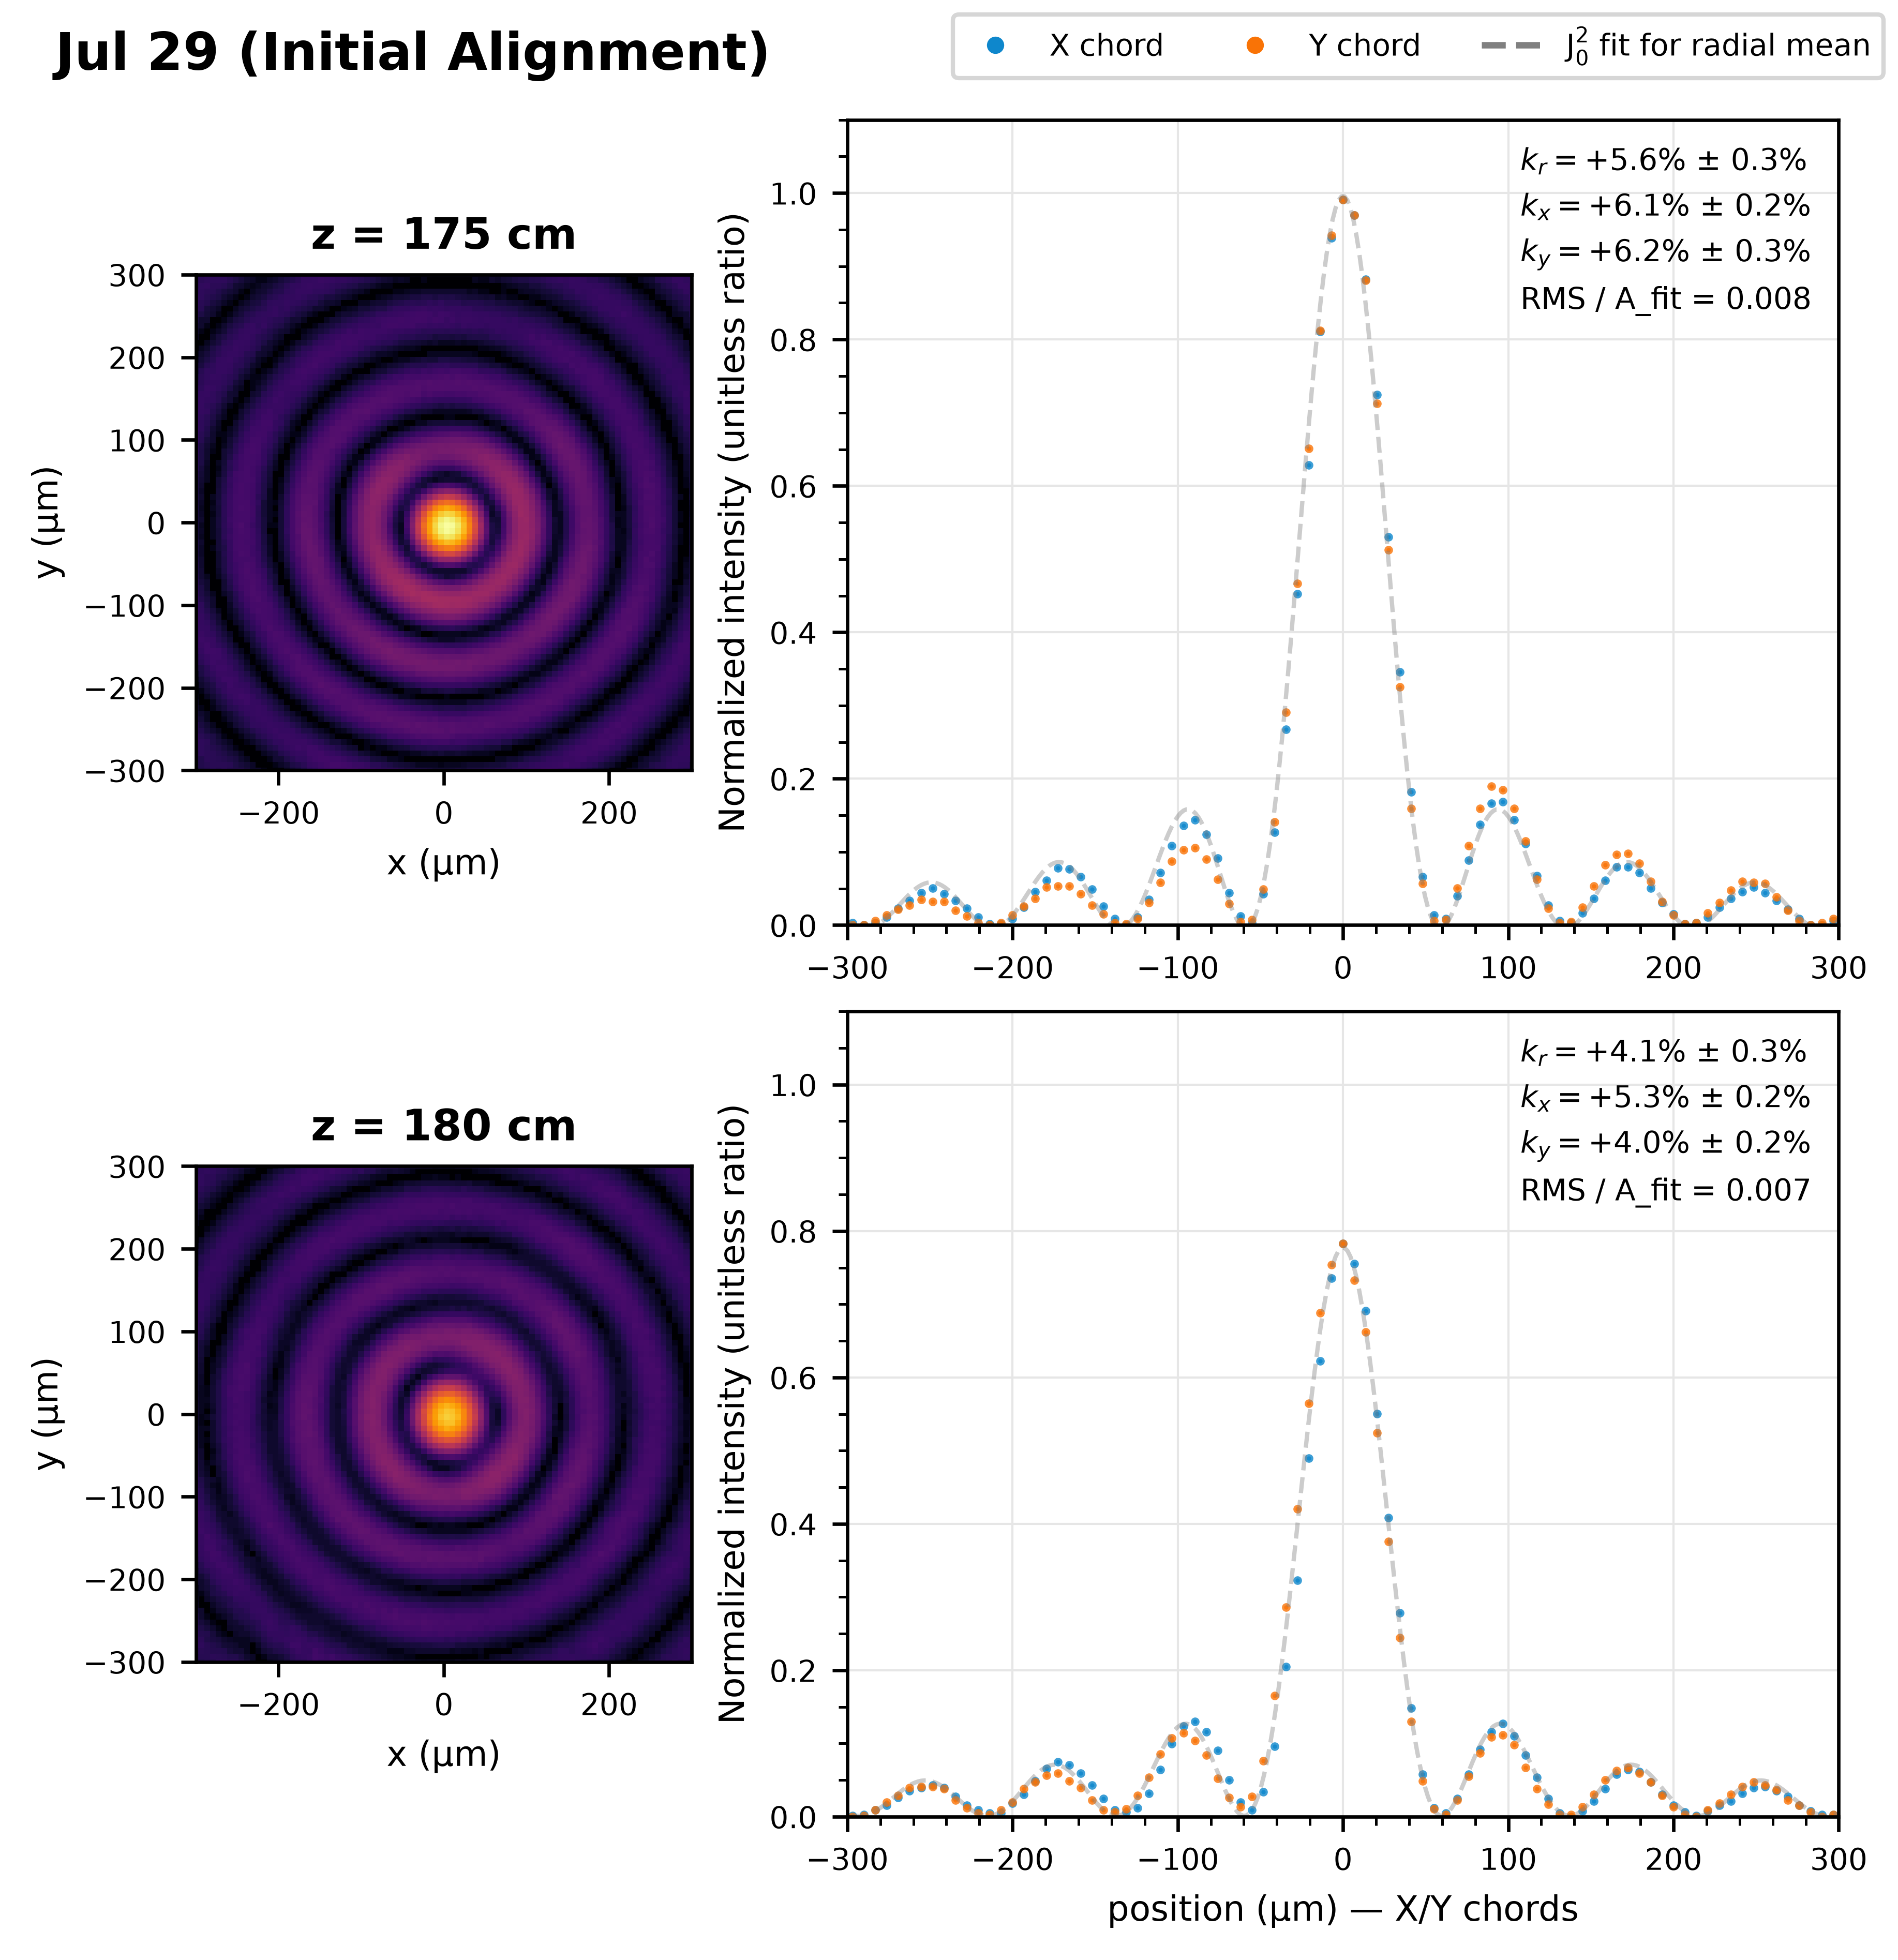

saved images/final_report_calcs_2026_08_10/placement_cmp_report_aug3.png


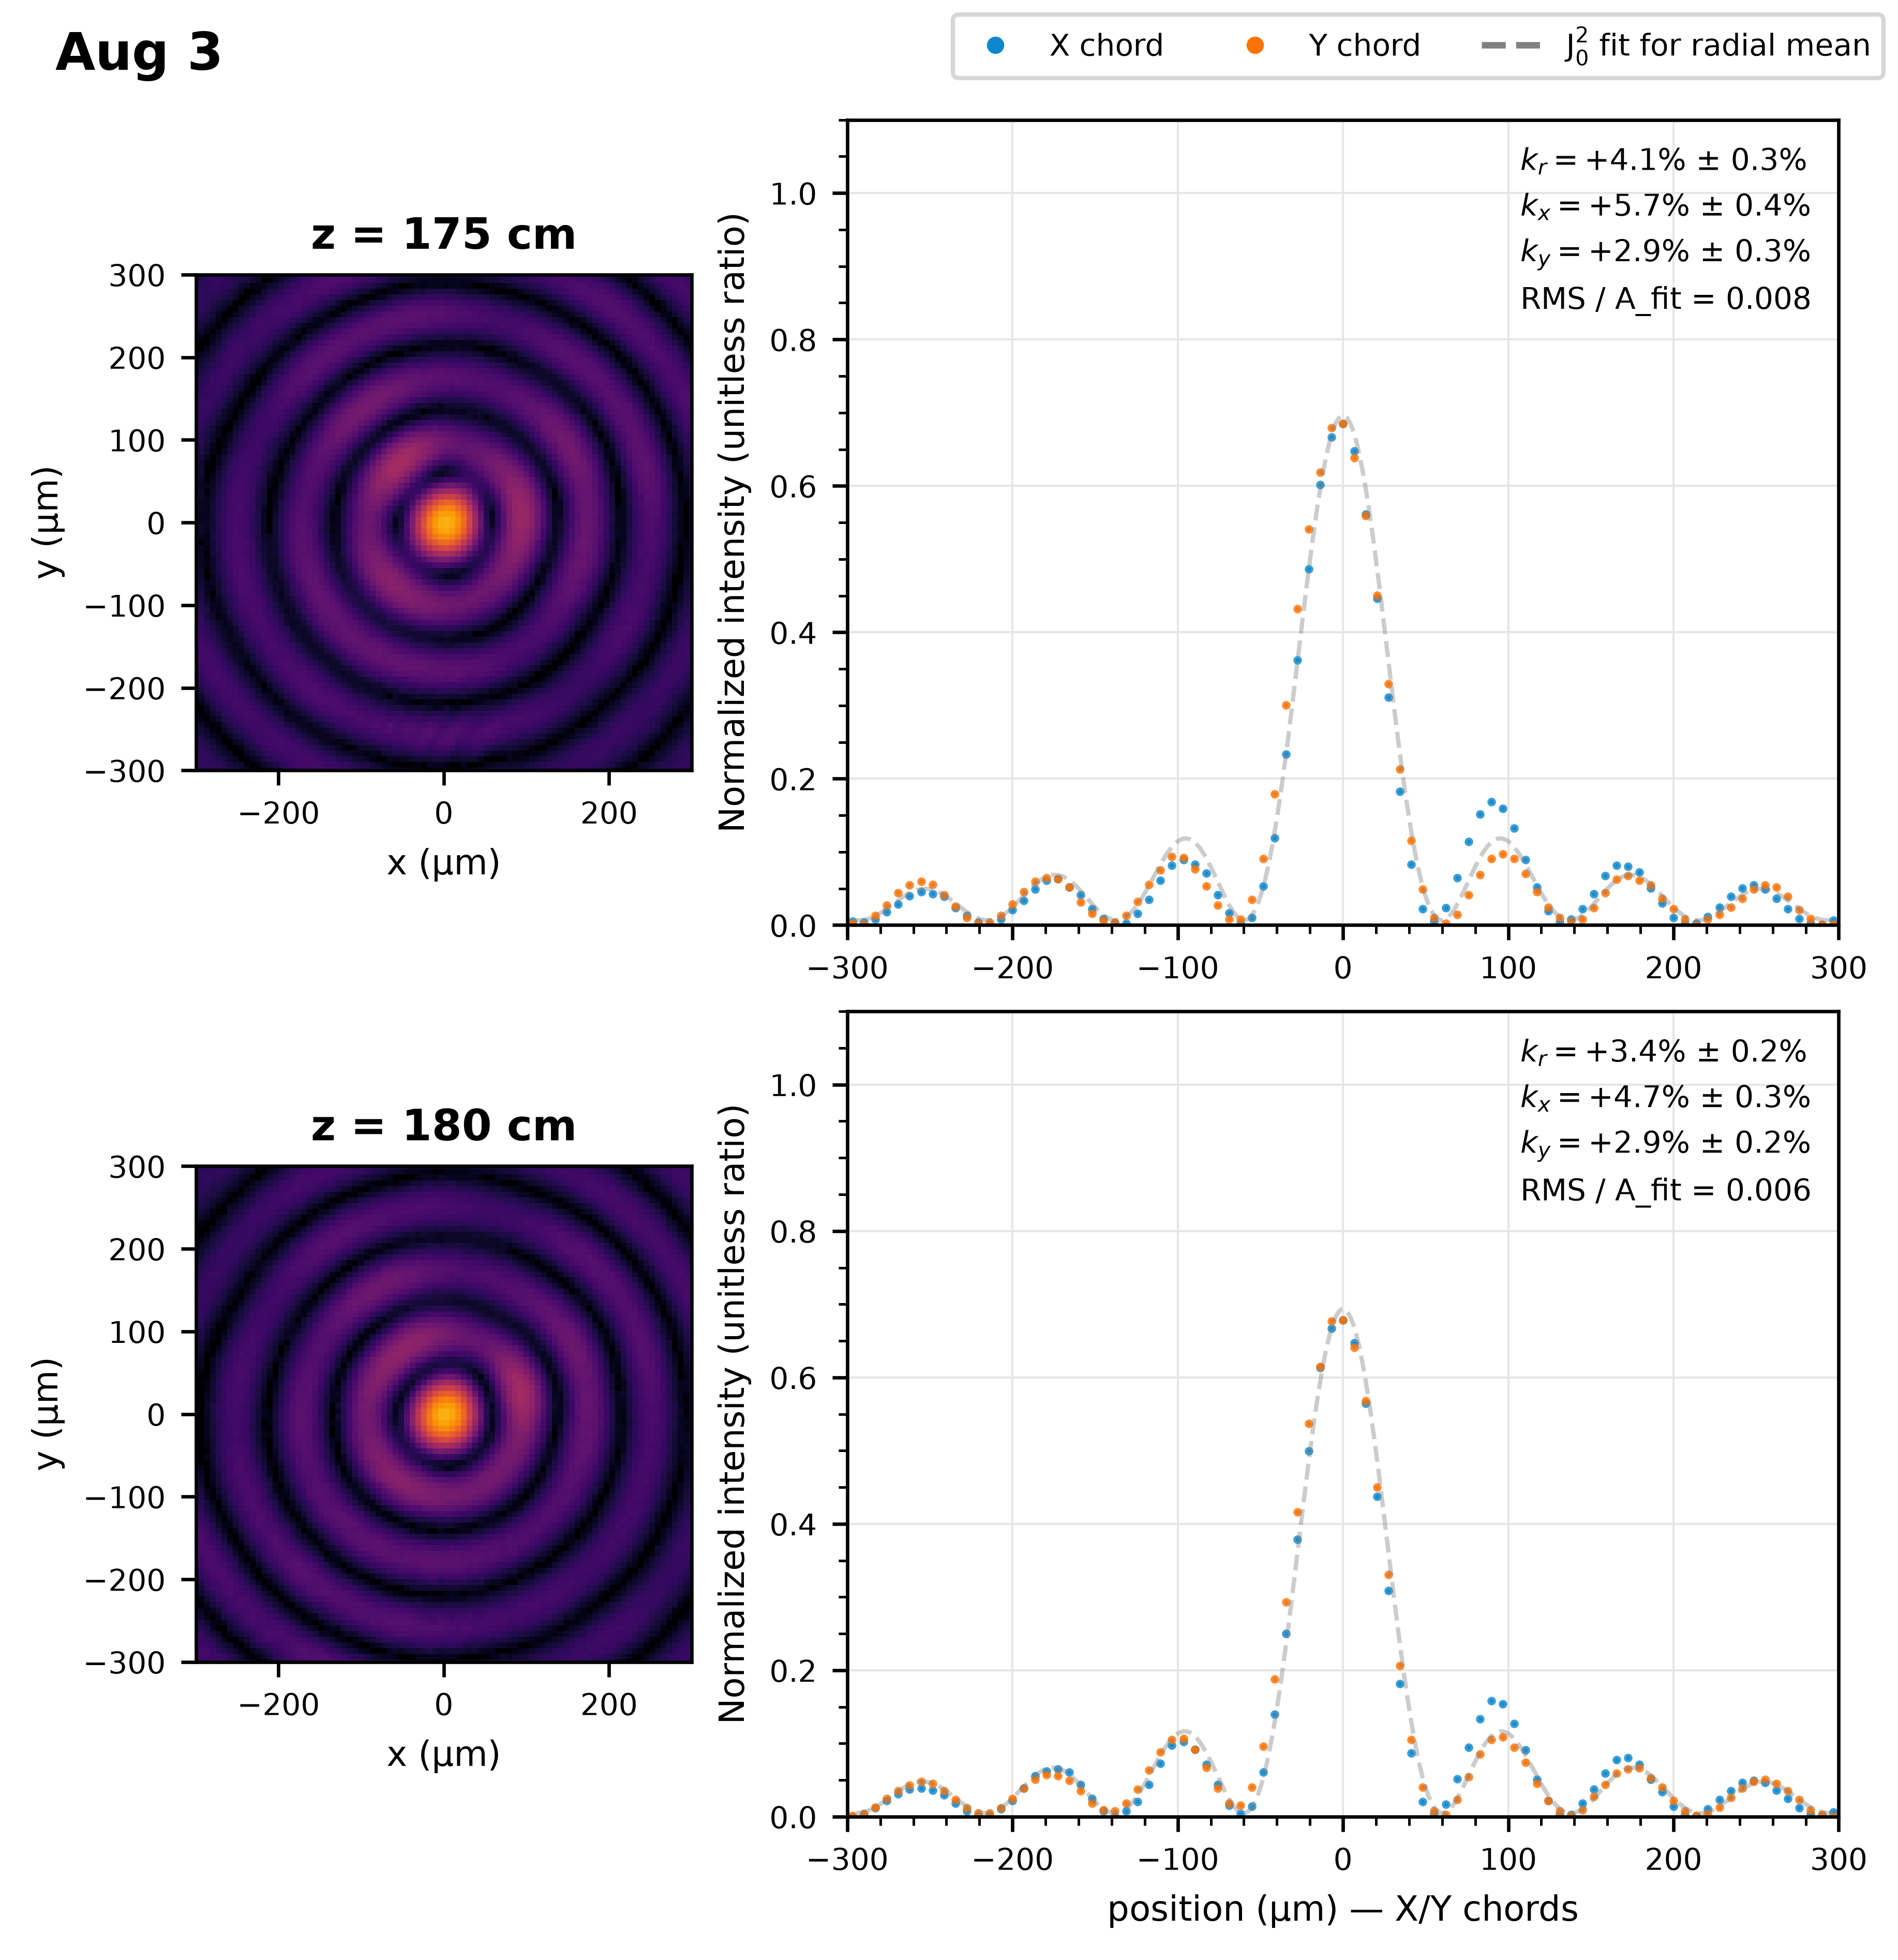

In [184]:
# --- two-figure variant: one figure per day, for side-by-side placement ------
# Same picks and the SAME global-peak normalization G as the combined figure
# above (shared across both figures, so the [0,1] scale stays absolute
# day-to-day and the Aug 3 amplitude drop remains visible). Each figure:
# 2 rows (z = 175, 180) x [image, fit], styled like the combined version,
# saved separately for LaTeX minipage/subfigure placement.
# Chord/fit legend only on the Jul 29 figure — in the paper the two sit
# side by side under one caption, so one legend serves both.
for day, lab in (("jul29", "Jul 29 (Initial Alignment)"), ("aug3", "Aug 3")):
    fig, axes2 = plt.subplots(len(ROWS_RPT), 2, figsize=(6.0, 6.2),
                              squeeze=False, width_ratios=[1, 2],
                              layout="constrained", dpi=600)
    for y0, (ax_im, ax_pr) in zip(ROWS_RPT, axes2):
        f = pc_picks[(y0, day)]
        ax_im.imshow(np.sqrt(np.clip(f["rt"] / G, 0, 1)), cmap=cmap_pc,
                     vmin=0, vmax=1, interpolation="nearest",
                     extent=[-497, 497, -497, 497])
        ax_im.set_title(f"z = {f['y']:.0f} cm", fontsize=10,
                        fontweight="bold")
        ax_im.set_xlim(-300, 300)
        ax_im.set_ylim(-300, 300)
        ax_im.set_xlabel("x (µm)", fontsize=8)
        ax_im.set_ylabel("y (µm)", fontsize=8)
        ax_im.tick_params(labelsize=7)

        ax_pr.plot(f["x_u"], f["Ix"] / G, ".", ms=2,
                   color="xkcd:water blue", alpha=0.8)
        ax_pr.plot(f["z_u"], f["Iz"] / G, ".", ms=2,
                   color="xkcd:orange", alpha=0.8)
        ax_pr.plot(u_fine, pc_j0sq(u_fine, *f["pr"]) / G, ls="--",
                   color="grey", lw=1, alpha=0.40)
        ax_pr.set_xlim(-300, 300)
        ax_pr.set_ylim(0, 1.10)
        ax_pr.set_ylabel("Normalized intensity (unitless ratio)", fontsize=8)
        krdev = f["pr"][1] / KR3 - 1
        krerr = f["perr_r"][1] / KR3
        kxdev, kxerr = f["px"][1] / KR3 - 1, f["px_err"][1] / KR3
        # dataset z axis = report y axis
        kydev, kyerr = f["pz"][1] / KR3 - 1, f["pz_err"][1] / KR3
        ax_pr.legend(handles=[
            plt.Line2D([], [], ls="",
                       label=f"$k_r=${krdev:+.1%} ± {krerr:.1%}"),
            plt.Line2D([], [], ls="",
                       label=f"$k_x=${kxdev:+.1%} ± {kxerr:.1%}"),
            plt.Line2D([], [], ls="",
                       label=f"$k_y=${kydev:+.1%} ± {kyerr:.1%}"),
            plt.Line2D([], [], ls="",
                       label=f"RMS / A_fit = {f['rms_r']:.3f}"),
        ], loc="upper right", fontsize=7, frameon=False)
        ax_pr.tick_params(labelsize=7)
        ax_pr.minorticks_on()
        ax_pr.grid(True, which="major", color="0.9", lw=0.5)
    axes2[-1][1].set_xlabel("position (µm) — X/Y chords", fontsize=8)
    fig.legend(handles=[
            plt.Line2D([], [], marker=".", ls="", color="xkcd:water blue",
                       label="X chord"),
            plt.Line2D([], [], marker=".", ls="", color="xkcd:orange",
                       label="Y chord"),
            plt.Line2D([], [], ls="--", color="grey", label="J$_0^2$ fit for radial mean")],
            loc="outside upper right", fontsize=7, ncol=3)
    fig.suptitle(lab, fontsize=12, fontweight="bold", x=0.02, ha="left")
    save_fig(f"placement_cmp_report_{day}")
    plt.show()